# YZM0206 Proje - EuroSAT RGB Veri Hazırlama

Bu notebookta EuroSAT RGB veri seti, transfer learning tabanlı görüntü sınıflandırma deneyleri için hazırlanmıştır. Amaç, model eğitimine geçmeden önce veri setinin sınıf yapısını, örnek görüntülerini, sınıf dağılımını, ham görüntü boyutlarını ve eğitimde kullanılacak veri pipeline mantığını kontrol etmektir.

Bu projede baseline CNN modeli ana referans olarak sade mimariyle değerlendirilecektir. Aynı CNN yapısının augmentation kullanan b versiyonu ayrı bir notebookta tutulacak, transfer learning modellerinde ise genelleme etkisini görmek için augmentation kullanılacaktır.

Bu aşamada yapılan işlemler:

1. EuroSAT RGB veri setinin indirilmesi ve dosya bütünlüğünün kontrol edilmesi
2. Sınıf isimlerinin ve görüntü sayılarının çıkarılması
3. Her sınıftan örnek görüntülerin incelenmesi
4. Sınıf dağılımının değerlendirilmesi
5. Ham görüntü boyutlarının kontrol edilmesi
6. Train / validation / test ayrımının yapılması
7. TensorFlow veri pipeline'ının kontrol amaçlı oluşturulması
8. Normalizasyon ve augmentation işlemlerinin eğitim öncesi nasıl uygulanacağının gösterilmesi

## Kütüphaneler ve proje dizinleri

Bu bölümde kullanılacak temel kütüphaneler içe aktarılmıştır. Ayrıca veri, model ve figür çıktıları için proje klasörleri tanımlanmıştır. Rastgelelik içeren işlemlerde aynı sonuçlara daha yakın çıktılar alabilmek için sabit seed değerleri kullanılmıştır.

In [1]:
import hashlib
import random
import shutil
import urllib.request
import warnings
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
import tensorflow as tf
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid", context="talk")

try:
    import importlib
    importlib.import_module("google.colab.drive").mount("/content/drive")
except Exception:
    pass


def find_project_dir():
    current = Path.cwd().resolve()
    candidates = [current, *current.parents]

    for root in [Path("/content") / "drive" / "MyDrive", Path("/content") / "drive" / "Shareddrives"]:
        project_candidate = root / "YZM0206 Proje"
        if project_candidate.exists():
            candidates.append(project_candidate)

    for candidate in candidates:
        if (candidate / "notebooks").exists() and (candidate / "data").exists():
            return candidate

    raise FileNotFoundError("Proje klasörü bulunamadı. Notebook proje klasörü içinden çalıştırılmalıdır.")


PROJECT_DIR = find_project_dir()
DATA_DIR = PROJECT_DIR / "data"
RAW_DIR = DATA_DIR / "raw"
PROCESSED_DIR = DATA_DIR / "processed"
ZIP_PATH = RAW_DIR / "EuroSAT.zip"
SPLIT_ZIP_PATH = PROCESSED_DIR / "eurosat_split_seed42.zip"

LOCAL_WORK_DIR = Path("/content/eurosat_work") if Path("/content").exists() else DATA_DIR / "local_work"
LOCAL_RAW_DIR = LOCAL_WORK_DIR / "raw"
LOCAL_ZIP_PATH = LOCAL_RAW_DIR / "EuroSAT.zip"
EXTRACT_DIR = LOCAL_RAW_DIR / "eurosat"
IMAGE_DIR = EXTRACT_DIR / "2750"

SPLIT_ROOT = LOCAL_WORK_DIR / "split_seed42"
SPLIT_DIRS = {
    "train": SPLIT_ROOT / "train",
    "valid": SPLIT_ROOT / "valid",
    "test": SPLIT_ROOT / "test",
}

FIGURES_DIR = PROJECT_DIR / "figures"
MODELS_DIR = PROJECT_DIR / "models"
REPORTS_DIR = PROJECT_DIR / "reports"

for directory in [RAW_DIR, PROCESSED_DIR, LOCAL_RAW_DIR, FIGURES_DIR, MODELS_DIR, REPORTS_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Hazırlık tamamlandı.")
print("TensorFlow:", tf.__version__)

Mounted at /content/drive
Hazırlık tamamlandı.
TensorFlow: 2.20.0


## Veri setini indirme ve hazırlama

EuroSAT RGB veri seti açık kaynak arşiv üzerinden indirilmiştir. Ham arşiv `data/raw` altında saklanmış, görüntüler ise çalışma sırasında okunabilir klasör yapısına çıkarılmıştır.

Bu adımda amaç veri kaynağını sabitlemek, dosya bütünlüğünü kontrol etmek ve sonraki deneylerde aynı görüntü kümesini kullanmaktır. Grafik, model ve rapor çıktıları proje klasörlerinde tutulacaktır.

In [2]:
EUROSAT_URL = "https://huggingface.co/datasets/torchgeo/eurosat/resolve/c877bcd43f099cd0196738f714544e355477f3fd/EuroSAT.zip"
EUROSAT_MD5 = "c8fa014336c82ac7804f0398fcb19387"
EXPECTED_IMAGE_COUNT = 27000


def file_md5(path):
    md5 = hashlib.md5()
    with Path(path).open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            md5.update(chunk)
    return md5.hexdigest()


def download_file(url, output_path):
    output_path.parent.mkdir(parents=True, exist_ok=True)
    request = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})

    with urllib.request.urlopen(request) as response, output_path.open("wb") as out_file:
        shutil.copyfileobj(response, out_file)


def count_images(directory):
    if not directory.exists():
        return 0
    return sum(1 for _ in directory.glob("*/*.jpg"))


if not ZIP_PATH.exists() or file_md5(ZIP_PATH) != EUROSAT_MD5:
    print("EuroSAT arşivi indiriliyor...")
    download_file(EUROSAT_URL, ZIP_PATH)

if file_md5(ZIP_PATH) != EUROSAT_MD5:
    raise ValueError("İndirilen zip dosyasının bütünlük kontrolü başarısız oldu.")

if not LOCAL_ZIP_PATH.exists() or file_md5(LOCAL_ZIP_PATH) != EUROSAT_MD5:
    print("Zip dosyası çalışma alanına kopyalanıyor...")
    shutil.copy2(ZIP_PATH, LOCAL_ZIP_PATH)

if count_images(IMAGE_DIR) != EXPECTED_IMAGE_COUNT:
    print("Veri seti çalışma alanına çıkarılıyor...")

    if EXTRACT_DIR.exists():
        shutil.rmtree(EXTRACT_DIR)
    EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(LOCAL_ZIP_PATH, "r") as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

if count_images(IMAGE_DIR) != EXPECTED_IMAGE_COUNT:
    raise RuntimeError("Veri seti eksik çıkarıldı. Zip çıkarma işlemi tamamlanmadı.")

print("Zip dosyası hazır:", ZIP_PATH.name)
print("MD5:", file_md5(ZIP_PATH))
print("Toplam görüntü sayısı:", count_images(IMAGE_DIR))

EuroSAT arşivi indiriliyor...
Zip dosyası çalışma alanına kopyalanıyor...
Veri seti çalışma alanına çıkarılıyor...
Zip dosyası hazır: EuroSAT.zip
MD5: c8fa014336c82ac7804f0398fcb19387
Toplam görüntü sayısı: 27000


## Sınıf yapısı

EuroSAT RGB veri seti 10 farklı arazi örtüsü / arazi kullanımı sınıfından oluşmaktadır. Çıktıda toplam 27.000 görüntü olduğu ve sınıfların şu şekilde okunduğu görülmektedir: AnnualCrop, Forest, HerbaceousVegetation, Highway, Industrial, Pasture, PermanentCrop, Residential, River ve SeaLake.

Bu kontrol önemlidir; çünkü sonraki model notebooklarında çıkış katmanı 10 sınıflı olarak kurulacaktır. Sınıf sayısı yanlış okunursa modelin son katmanı ve classification report değerlendirmesi de hatalı olurdu.

In [3]:
class_names = sorted([path.name for path in IMAGE_DIR.iterdir() if path.is_dir()])
image_paths = sorted(IMAGE_DIR.glob("*/*.jpg"))

print("Sınıf sayısı:", len(class_names))
print("Görüntü sayısı:", len(image_paths))
print("Sınıflar:")

for i, name in enumerate(class_names):
    print(i, name)

Sınıf sayısı: 10
Görüntü sayısı: 27000
Sınıflar:
0 AnnualCrop
1 Forest
2 HerbaceousVegetation
3 Highway
4 Industrial
5 Pasture
6 PermanentCrop
7 Residential
8 River
9 SeaLake


## Örnek görüntüler

Veri setinin görsel yapısını incelemek için her sınıftan birer örnek görüntü seçilmiştir. Bu kontrol, sınıfların görsel olarak ne kadar ayırt edilebilir olduğunu anlamak ve olası sınıf benzerliklerini önceden görmek için yapılmıştır.

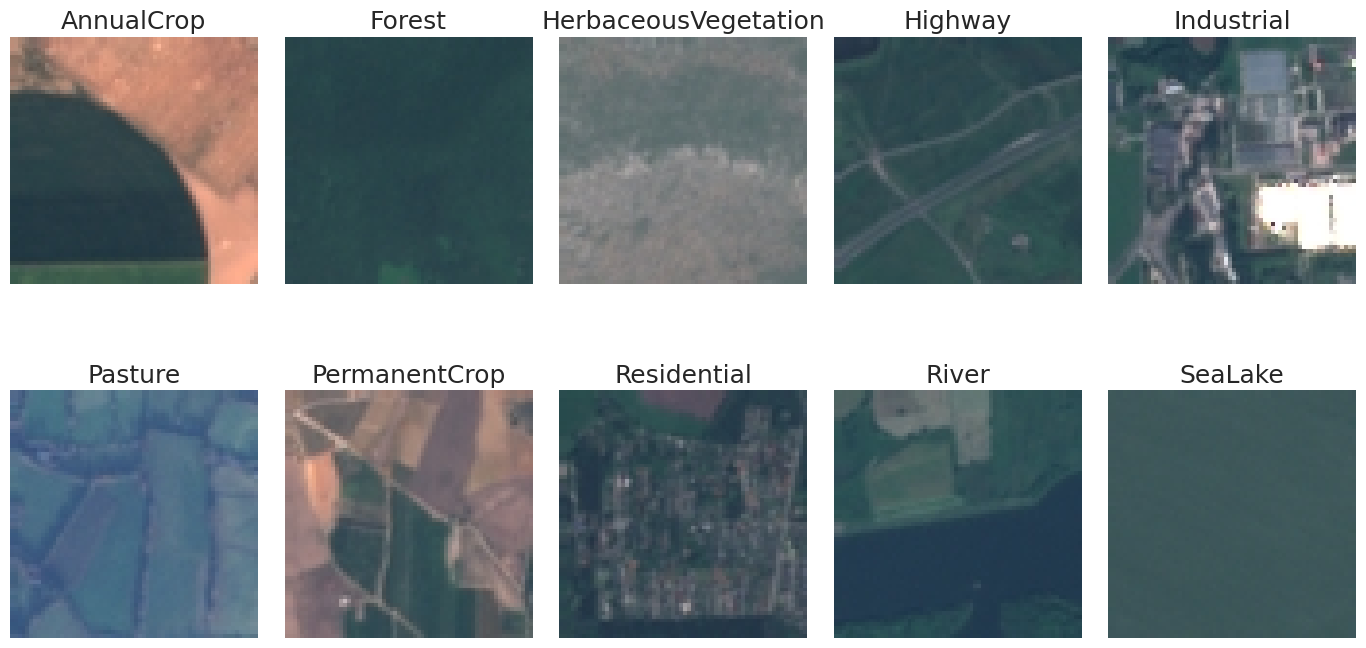

In [4]:
sample_paths = []

for class_name in class_names:
    class_images = list((IMAGE_DIR / class_name).glob("*.jpg"))
    sample_paths.append(random.choice(class_images))

plt.figure(figsize=(14, 8))

for i, image_path in enumerate(sample_paths):
    image = plt.imread(image_path)
    label = image_path.parent.name

    plt.subplot(2, 5, i + 1)
    plt.imshow(image)
    plt.title(label)
    plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

İlk incelemede görüntülerin küçük uydu kesitleri olduğu görülmektedir. Örneklerde `Residential`, `Forest` ve `SeaLake` sınıfları daha belirgin görsel yapılara sahiptir. `Residential` görüntülerinde yapılaşma dokusu, `Forest` görüntülerinde yoğun yeşil doku, `SeaLake` görüntülerinde ise su yüzeyi daha kolay ayırt edilmektedir.

Buna karşılık `AnnualCrop`, `HerbaceousVegetation`, `Pasture` ve `PermanentCrop` sınıfları renk ve doku bakımından birbirine daha yakındır. Bu durum model sonuçlarında özellikle tarım ve bitki örtüsü sınıflarının hata analizinde dikkate alınacaktır.

## Sınıf dağılımı

Model eğitimi öncesinde sınıf dağılımı incelenmiştir. Sınıflar arasında ciddi bir dengesizlik varsa model çoğunluk sınıflarına daha fazla eğilim gösterebilir. Bu nedenle her sınıftaki görüntü sayısı tablo ve grafik ile kontrol edilmiştir.

In [5]:
counts_df = pd.DataFrame({
    "class": class_names,
    "count": [len(list((IMAGE_DIR / class_name).glob("*.jpg"))) for class_name in class_names]
})

counts_df

,class,count
0,AnnualCrop,3000
1,Forest,3000
2,HerbaceousVegetation,3000
3,Highway,2500
4,Industrial,2500
5,Pasture,2000
6,PermanentCrop,2500
7,Residential,3000
8,River,2500
9,SeaLake,3000


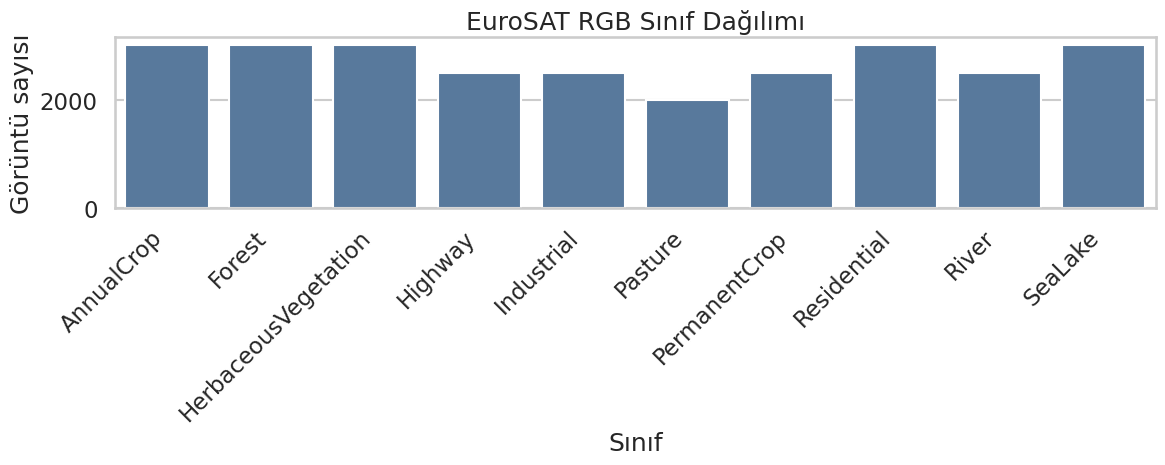

In [6]:
plt.figure(figsize=(12, 5))
sns.barplot(data=counts_df, x="class", y="count", color="#4C78A8")
plt.xticks(rotation=45, ha="right")
plt.title("EuroSAT RGB Sınıf Dağılımı")
plt.xlabel("Sınıf")
plt.ylabel("Görüntü sayısı")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

Sınıf dağılımı tamamen eşit değildir; ancak ciddi bir dengesizlik de yoktur. AnnualCrop, Forest, HerbaceousVegetation, Residential ve SeaLake sınıflarında 3000'er görüntü bulunmaktadır. Highway, Industrial, PermanentCrop ve River sınıflarında 2500'er görüntü vardır. En az örneğe sahip sınıf ise 2000 görüntü ile Pasture sınıfıdır.

En büyük sınıflar ile en küçük sınıf arasındaki oran 3000 / 2000 = 1.5'tir. Bu oran görüntü sınıflandırma deneyleri için yönetilebilir düzeydedir. Bu nedenle ilk deneylerde class weight kullanılmamış, bunun yerine stratified split ile her sınıfın train, validation ve test kümelerinde benzer oranlarda temsil edilmesi tercih edilmiştir.

## Ham görüntü boyutu kontrolü

Görüntüler modele verilmeden önce ham çözünürlükleri kontrol edilmiştir. Çıktıya göre veri setindeki 27.000 görüntünün tamamı 64x64 piksel boyutunda ve 3 kanallı RGB formatındadır.

Bu sonuç veri setinin kendi içinde tutarlı olduğunu gösterir. Farklı boyutlarda veya kanal sayısında görüntüler olsaydı model eğitiminden önce ek temizleme ya da dönüştürme adımı gerekebilirdi. Daha sonra model pipeline içinde görüntüler 224x224 boyutuna yeniden ölçeklenecektir; bu işlem ham dosyaları değiştirmez, yalnızca modele verilen tensorların boyutunu standartlaştırır.

In [8]:
from PIL import Image

image_sizes = []

for path in image_paths:
    with Image.open(path) as image:
        image_sizes.append({
            "class": path.parent.name,
            "height": image.height,
            "width": image.width,
            "channels": len(image.getbands())
        })

sizes_df = pd.DataFrame(image_sizes)

sizes_df.value_counts(
    ["height", "width", "channels"]
).reset_index(name="count")

,height,width,channels,count
0,64,64,3,27000


## Train / validation / test ayrımı

Veri seti %70 eğitim, %15 validation ve %15 test olacak şekilde ayrılmıştır. Çıktıda bu ayrımın 18.900 train, 4.050 validation ve 4.050 test görüntüsü ürettiği görülmektedir.

Ayrım yapılırken `stratify` kullanılmıştır; böylece her sınıfın train, validation ve test kümelerinde benzer oranda temsil edilmesi sağlanmıştır. Oluşturulan split daha sonra tek dosya olarak `data/processed/eurosat_split_seed42.zip` altında saklanmıştır. Bu dosya sonraki tüm model notebooklarında ortak veri ayrımı olarak kullanılacaktır.

In [9]:
paths = np.array([str(path) for path in image_paths])
labels = np.array([path.parent.name for path in image_paths])

train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    paths,
    labels,
    test_size=0.30,
    random_state=42,
    stratify=labels
)

valid_paths, test_paths, valid_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.50,
    random_state=42,
    stratify=temp_labels
)

print("Train:", len(train_paths))
print("Validation:", len(valid_paths))
print("Test:", len(test_paths))

Train: 18900
Validation: 4050
Test: 4050


In [11]:
def count_split_images(split_dir):
    if not split_dir.exists():
        return 0
    return sum(1 for _ in split_dir.glob("*/*.jpg"))


def split_is_ready():
    expected = {
        "train": len(train_paths),
        "valid": len(valid_paths),
        "test": len(test_paths),
    }
    return all(count_split_images(SPLIT_DIRS[name]) == count for name, count in expected.items())


def split_zip_counts(zip_path):
    counts = {"train": 0, "valid": 0, "test": 0}

    if not zip_path.exists():
        return counts

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        for name in zip_ref.namelist():
            parts = name.split("/")
            if len(parts) == 3 and parts[0] in counts and name.lower().endswith(".jpg"):
                counts[parts[0]] += 1

    return counts


def split_zip_is_ready():
    expected = {
        "train": len(train_paths),
        "valid": len(valid_paths),
        "test": len(test_paths),
    }
    return split_zip_counts(SPLIT_ZIP_PATH) == expected


def copy_split(split_name, split_paths):
    split_dir = SPLIT_DIRS[split_name]

    for path in split_paths:
        source = Path(path)
        target_dir = split_dir / source.parent.name
        target_dir.mkdir(parents=True, exist_ok=True)
        shutil.copy2(source, target_dir / source.name)


def create_split_zip():
    temp_zip_path = SPLIT_ZIP_PATH.with_suffix(".tmp.zip")

    if temp_zip_path.exists():
        temp_zip_path.unlink()

    with zipfile.ZipFile(temp_zip_path, "w", compression=zipfile.ZIP_STORED) as zip_ref:
        for image_path in sorted(SPLIT_ROOT.rglob("*.jpg")):
            archive_name = image_path.relative_to(SPLIT_ROOT).as_posix()
            zip_ref.write(image_path, archive_name)

    temp_zip_path.replace(SPLIT_ZIP_PATH)


if split_is_ready():
    print("Split klasörleri zaten hazır.")
else:
    for split_dir in SPLIT_DIRS.values():
        if split_dir.exists():
            shutil.rmtree(split_dir)

    copy_split("train", train_paths)
    copy_split("valid", valid_paths)
    copy_split("test", test_paths)
    print("Split klasörleri oluşturuldu.")

if split_zip_is_ready():
    print("Split zip dosyası zaten hazır.")
else:
    create_split_zip()
    print("Split zip dosyası oluşturuldu:", SPLIT_ZIP_PATH.name)

split_zip_counts(SPLIT_ZIP_PATH)

Split klasörleri zaten hazır.
Split zip dosyası oluşturuldu: eurosat_split_seed42.zip


{'train': 18900, 'valid': 4050, 'test': 4050}

## Split sonrası sınıf kontrolü

Ayrım işleminden sonra her sınıfın train, validation ve test klasörlerindeki görüntü sayıları tekrar kontrol edilmiştir. Sonuçlar stratified split işleminin sınıf dağılımını koruduğunu göstermektedir.

3000 görüntülü sınıflar için dağılım 2100 train, 450 validation ve 450 test şeklindedir. 2500 görüntülü sınıflar için dağılım 1750 train, 375 validation ve 375 test olmuştur. 2000 görüntülü Pasture sınıfında ise 1400 train, 300 validation ve 300 test görüntüsü bulunmaktadır.

Bu kontrol önemli bir güvence sağlar: model sonuçları sınıf dağılımı bozulmuş bir splitten değil, dengesi korunmuş bir veri ayrımından elde edilmiştir.

In [12]:
split_counts = []

for split_name, split_dir in SPLIT_DIRS.items():
    for class_name in class_names:
        split_counts.append({
            "split": split_name,
            "class": class_name,
            "count": len(list((split_dir / class_name).glob("*.jpg")))
        })

split_counts_df = pd.DataFrame(split_counts)
split_counts_df.pivot(index="class", columns="split", values="count")

split,test,train,valid
class,,,
AnnualCrop,450,2100,450
Forest,450,2100,450
HerbaceousVegetation,450,2100,450
Highway,375,1750,375
Industrial,375,1750,375
Pasture,300,1400,300
PermanentCrop,375,1750,375
Residential,450,2100,450
River,375,1750,375


## TensorFlow veri pipeline

Bu bölümde hazırlanan train, validation ve test split klasörlerinden TensorFlow veri kümeleri kontrol amaçlı oluşturulmuştur. Çıktıda TensorFlow'un 18.900 train, 4.050 validation ve 4.050 test görüntüsünü doğru şekilde bulduğu görülmektedir.

Buradaki amaç modeli eğitmek değil, veri klasörlerinin TensorFlow tarafından doğru okunabildiğini ve eğitim sırasında uygulanacak dönüşümlerin nasıl çalıştığını göstermektir. Sınıf isimleri de beklenen 10 sınıfla aynı sırada okunmuştur.

Önemli nokta: Bu işlem ham görüntü dosyalarını kalıcı olarak değiştirmez. `.jpg` dosyaları hâlâ orijinal 64x64 RGB görüntülerdir. `image_dataset_from_directory` fonksiyonu görüntüleri okurken geçici olarak 224x224 boyutunda tensorlara dönüştürür.

In [13]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

train_data = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIRS["train"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=42
)

valid_data = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIRS["valid"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    SPLIT_DIRS["test"],
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False
)

class_names_from_tf = train_data.class_names
print(class_names_from_tf)

Found 18900 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
Found 4050 files belonging to 10 classes.
['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


## Normalizasyon

Bu bölümde piksel değerleri 0-255 aralığından 0-1 aralığına çevrilmiştir. Buradaki normalizasyon da ham dosyaları değiştirmez; yalnızca TensorFlow pipeline içinde üretilen görüntü tensorlarına uygulanır.

Normalizasyon yapılmazsa model yine eğitilebilir, ancak büyük piksel değerleri eğitim sürecini daha kararsız hale getirebilir. Bu işlem, sinir ağının daha düzenli sayısal aralıklarla çalışmasını sağlayarak öğrenme sürecini daha stabil hale getirir. Model eğitimi yapılan notebooklarda bu adım yeniden uygulanacaktır; çünkü her notebook kendi eğitim pipeline'ını bağımsız olarak kurmalıdır.

In [14]:
def normalize_image(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    return image, label

train_data = train_data.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
valid_data = valid_data.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)
test_data = test_data.map(normalize_image, num_parallel_calls=AUTOTUNE).prefetch(AUTOTUNE)

print("Veri pipeline hazır.")

Veri pipeline hazır.


## Augmentation stratejisi

Augmentation yalnızca eğitim verisine uygulanacaktır. Validation ve test kümeleri modelin gerçek performansını ölçmek için sabit tutulmalıdır. Uydu görüntülerinde yön bilgisi çoğu zaman doğrudan sınıf etiketiyle bağlı olmadığı için çevirme ve döndürme işlemleri kullanılabilir. Zoom, translation ve düşük seviyeli contrast değişimi ise modelin küçük konum ve görünüm farklılıklarına daha dayanıklı olmasına yardımcı olur.

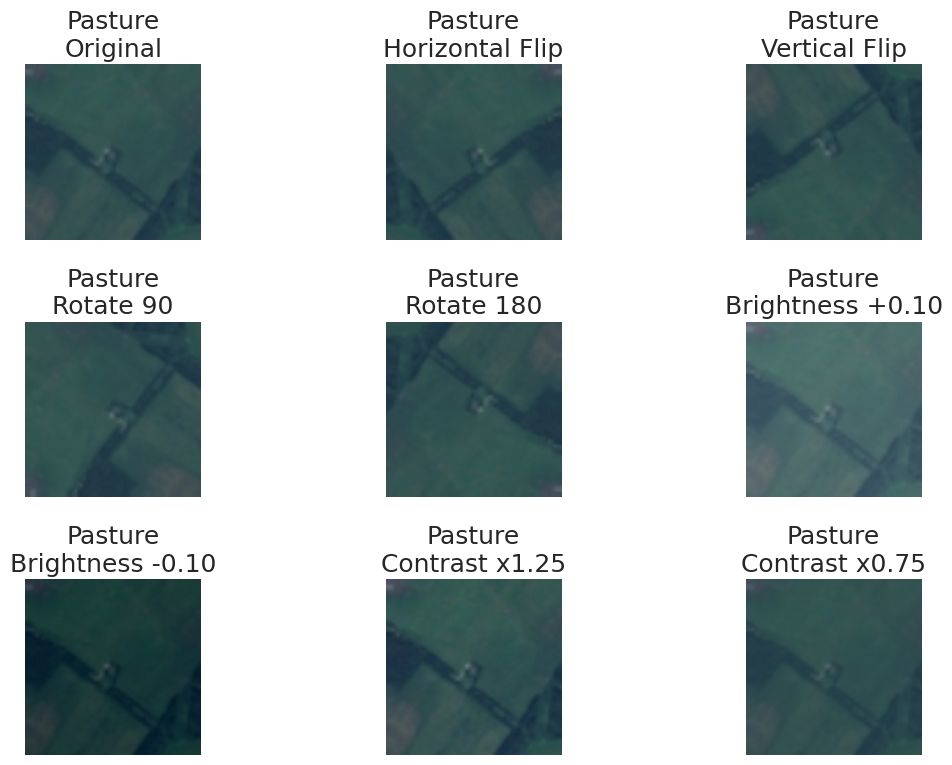

In [15]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.10),
    tf.keras.layers.RandomTranslation(0.05, 0.05),
    tf.keras.layers.RandomContrast(0.10),
], name="data_augmentation")

image_batch, label_batch = next(iter(train_data))
image = image_batch[0]
label = label_batch[0]
label_name = class_names_from_tf[int(label.numpy())]

augmented_examples = [
    ("Original", image),
    ("Horizontal Flip", tf.image.flip_left_right(image)),
    ("Vertical Flip", tf.image.flip_up_down(image)),
    ("Rotate 90", tf.image.rot90(image, k=1)),
    ("Rotate 180", tf.image.rot90(image, k=2)),
    ("Brightness +0.10", tf.image.adjust_brightness(image, delta=0.10)),
    ("Brightness -0.10", tf.image.adjust_brightness(image, delta=-0.10)),
    ("Contrast x1.25", tf.image.adjust_contrast(image, contrast_factor=1.25)),
    ("Contrast x0.75", tf.image.adjust_contrast(image, contrast_factor=0.75)),
]

plt.figure(figsize=(12, 8))

for i, (title, aug_image) in enumerate(augmented_examples):
    aug_image = tf.clip_by_value(aug_image, 0.0, 1.0)

    plt.subplot(3, 3, i + 1)
    plt.imshow(aug_image)
    plt.title(f"{label_name}\n{title}")
    plt.axis("off")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "augmentation_examples.png", dpi=150, bbox_inches="tight")
plt.show()

Bu örnekte aynı görüntü üzerinde farklı augmentation işlemlerinin etkisi ayrı ayrı gösterilmiştir. Eğitim sırasında kullanılacak dönüşüm katmanı bu işlemleri rastgele uygulayacaktır.

Görsel inceleme sonucunda geometrik dönüşümlerin uydu görüntülerinde anlamlı olduğu görülmektedir; çünkü görüntünün yönü veya küçük konum değişimleri çoğu sınıfta etiketi değiştirmez. Brightness ve contrast örnekleri yalnızca olası görsel etkiyi göstermek için incelenmiştir. Ana transfer learning deneylerinde renk bilgisini fazla bozabilecek işlemler yerine geometrik augmentation tercih edilmiştir.

## Notebook özeti

Bu notebook sonunda EuroSAT RGB veri seti indirilmiş, dosya bütünlüğü kontrol edilmiş ve toplam 27.000 görüntünün 10 sınıfa ait olduğu doğrulanmıştır. Tüm görüntülerin 64x64x3 RGB formatında olması veri setinin boyut açısından tutarlı olduğunu göstermiştir.

Sınıf dağılımında en yüksek değer 3000, en düşük değer 2000 görüntüdür. Bu fark yönetilebilir düzeyde olduğu için class weight kullanılmamıştır. Veri seti stratified biçimde 18.900 train, 4.050 validation ve 4.050 test görüntüsüne ayrılmıştır.

Split yapısı `data/processed/eurosat_split_seed42.zip` dosyasına kaydedilmiştir. Sonraki model notebookları bu dosyayı kullanacağı için tüm modeller aynı train, validation ve test ayrımı üzerinde karşılaştırılacaktır.